<div style="background:linear-gradient(135deg,#4c1d95 0%,#6d28d9 55%,#a78bfa 100%);border-radius:18px;padding:32px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#ddd6fe;font-weight:700;text-transform:uppercase">Chapter 191 &middot; Capstone 29 &middot; Imbalanced Classification</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">Credit Card Fraud</div>
  <div style="font-size:15px;color:#ddd6fe;max-width:820px;line-height:1.6">Three standard answers to class imbalance produce the same ranking to three decimal places. Two of them multiply the predicted fraud rate by thirty-six, which makes them useless for the only calculation anyone wanted.</div>
</div>

In [1]:
import numpy as np, pandas as pd, warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss,
                             precision_recall_curve, roc_curve)
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.22,"axes.titleweight":"bold","axes.titlesize":12.5,"axes.titlelocation":"left"})
VI, DK, LT, MUT, GD, RD = "#6d28d9", "#4c1d95", "#a78bfa", "#94a3b8", "#047857", "#dc2626"

BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "capstone-credit-card-fraud.xlsx"
def load(sheet):
    try:    return pd.read_excel("../../data/" + fn, sheet_name=sheet)
    except FileNotFoundError: return pd.read_excel(BASE + fn, sheet_name=sheet)
raw  = load("Transactions")
plan = load("AnalysisPlan")
print("rows in the warehouse export:", f"{len(raw):,}")
raw.head()

rows in the warehouse export: 120,400


,transaction_id,transaction_day,amount,hour_of_day,customer_tenure_days,transactions_last_30d,foreign_merchant,online,new_device,distance_from_home_km,merchant_category_risk,chargeback_code_filed,is_fraud
0,T2023984,24,2.31,6,299,25,0,0,0,12.8,0.041,0,0
1,T2017726,18,14.96,20,1354,25,0,0,1,16.9,0.457,0,0
2,T2064569,65,21.39,14,487,33,0,0,0,596.4,0.227,0,0
3,T2002284,3,29.58,5,445,28,0,1,0,1.6,0.230,0,0
4,T2011587,12,44.38,13,2023,16,0,0,0,4.3,0.158,0,0


## Step 1 &middot; The decision, and what each error costs

In [2]:
for line in plan.analysis_plan.fillna(""):
    print(line)

AGREED WITH FRAUD OPERATIONS BEFORE ANY MODEL WAS FITTED.

THE DECISION. A flagged transaction is held and reviewed by an analyst. An unflagged one settles.
The model produces a queue, and the team can work about 400 reviews a day.

THE COST OF BEING WRONG, from operations, in dollars:
  a missed fraud        = the transaction amount, written off, plus 25 of handling
  a false positive      = 4 of analyst time, plus an estimated 12 of customer annoyance
  These are NOT symmetric and they are not even a fixed ratio: the cost of a miss depends
  on the amount. That rules out any single global threshold chosen from a curve.

M1 SPLIT: by time. The model will score future transactions, so it is validated on later ones.
   A random split would let it learn from transactions that had not happened yet.
M2 METRIC: PRECISION-RECALL AUC as the headline, never ROC-AUC. With 0.28 percent positives
   the false positive rate has a denominator of 120,000 and barely moves, so ROC flatters.
M3 IMBALAN

**The cost of a miss depends on the transaction.** That single sentence rules out choosing a threshold from any curve, because every such rule assumes both errors have a fixed price. Here a missed $8 coffee and a missed $2,000 laptop cost very different amounts, and the threshold has to know that.

## Step 2 &middot; Cleaning, and the accuracy trap

In [3]:
d = raw.drop_duplicates(subset="transaction_id").copy()
print(f"raw rows                  {len(raw):,}")
print(f"after the duplicate export {len(d):,}")
d.loc[d.distance_from_home_km == -1, "distance_from_home_km"] = np.nan
d = d.dropna(subset=["distance_from_home_km"])
print(f"with geolocation          {len(d):,}")
d = d[d.amount > 0].copy()
print(f"real purchases            {len(d):,}   (zero-amount rows are authorization holds)")

print(f"\nfraud rate                {d.is_fraud.mean():.4%}   ({d.is_fraud.sum()} of {len(d):,})")
print(f"accuracy of flagging NOTHING: {1-d.is_fraud.mean():.4%}")
print("\nThat number is why accuracy is not mentioned again in this notebook.")

raw rows                  120,400
after the duplicate export 120,000
with geolocation          119,694
real purchases            119,556   (zero-amount rows are authorization holds)

fraud rate                0.2660%   (318 of 119,556)
accuracy of flagging NOTHING: 99.7340%

That number is why accuracy is not mentioned again in this notebook.


## Step 3 &middot; Split by time, because that is how it will be used

In [4]:
d["night"] = d.hour_of_day.between(1, 5).astype(int)
d["log_amt"] = np.log1p(d.amount)
d["dev_online"] = d.new_device * d.online
d["foreign_night"] = d.foreign_merchant * d.night

F  = ["log_amt","night","customer_tenure_days","transactions_last_30d","foreign_merchant",
      "online","new_device","distance_from_home_km","merchant_category_risk"]
FX = F + ["dev_online", "foreign_night"]

tr, te = d[d.transaction_day <= 90], d[d.transaction_day > 90]
ytr, yte = tr.is_fraud.values, te.is_fraud.values
mu, sd = tr[FX].mean(), tr[FX].std()
print(f"train  days 1-90    {len(tr):,} transactions, {ytr.sum()} frauds ({ytr.mean():.3%})")
print(f"test   days 91-120  {len(te):,} transactions, {yte.sum()} frauds ({yte.mean():.4%})")
print("\nA random split would let the model learn from transactions that had not happened yet.")

train  days 1-90    89,973 transactions, 223 frauds (0.248%)
test   days 91-120  29,583 transactions, 95 frauds (0.3211%)

A random split would let the model learn from transactions that had not happened yet.


## Step 4 &middot; The leak, found before anything else

The warehouse table carries a column called `chargeback_code_filed`. It looks like a feature. Fit with it and see.

In [5]:
def fit_lr(cols, train, y, cols_mu=None, cols_sd=None):
    m_, s_ = (train[cols].mean(), train[cols].std()) if cols_mu is None else (cols_mu, cols_sd)
    mod = LogisticRegression(max_iter=3000).fit((train[cols]-m_)/s_, y)
    return mod, m_, s_

for cols, tag in [(FX, "honest features"), (FX + ["chargeback_code_filed"], "+ chargeback_code_filed")]:
    mod, m_, s_ = fit_lr(cols, tr, ytr)
    p = mod.predict_proba((te[cols]-m_)/s_)[:, 1]
    print(f"  {tag:26s} ROC-AUC {roc_auc_score(yte,p):.4f}   PR-AUC {average_precision_score(yte,p):.4f}")
print(f"\n  a random ranking scores PR-AUC = the base rate = {yte.mean():.4f}")
print("\nA chargeback code is filed WEEKS LATER, once a human has worked the case.")
print("At the moment the model must decide whether to hold the transaction, it does not exist.")

  honest features            ROC-AUC 0.9604   PR-AUC 0.2984
  + chargeback_code_filed    ROC-AUC 0.9997   PR-AUC 0.9818

  a random ranking scores PR-AUC = the base rate = 0.0032

A chargeback code is filed WEEKS LATER, once a human has worked the case.
At the moment the model must decide whether to hold the transaction, it does not exist.


**That is what leakage looks like: not an error, a triumph.** The column is real, it is in the warehouse, and it is 97 percent accurate about fraud. It is also unavailable at the only moment that matters. Everything below drops it.

## Step 5 &middot; The bake-off, and the baseline that wins

In [6]:
results = {}
mod, m_, s_ = fit_lr(F, tr, ytr)
results["logistic, additive"] = mod.predict_proba((te[F]-m_)/s_)[:, 1]
mod, m_, s_ = fit_lr(FX, tr, ytr)
results["logistic + 2 interactions"] = mod.predict_proba((te[FX]-m_)/s_)[:, 1]
results["gradient boosting"] = HistGradientBoostingClassifier(
    max_iter=200, learning_rate=0.05, max_leaf_nodes=8, min_samples_leaf=60,
    l2_regularization=1.0, random_state=1).fit(tr[F], ytr).predict_proba(te[F])[:, 1]
results["random forest"] = RandomForestClassifier(
    n_estimators=400, min_samples_leaf=25, random_state=1, n_jobs=-1
    ).fit(tr[F], ytr).predict_proba(te[F])[:, 1]

print(f"{'model':30s}{'ROC-AUC':>9}{'PR-AUC':>9}{'lift':>7}{'Brier':>10}")
for nm, p in results.items():
    ap = average_precision_score(yte, p)
    print(f"  {nm:28s}{roc_auc_score(yte,p):>9.4f}{ap:>9.4f}{ap/yte.mean():>7.0f}{brier_score_loss(yte,p):>10.5f}")

model                           ROC-AUC   PR-AUC   lift     Brier
  logistic, additive             0.9554   0.2752     86   0.00269
  logistic + 2 interactions      0.9604   0.2984     93   0.00264
  gradient boosting              0.9565   0.2584     80   0.00272
  random forest                  0.9364   0.2496     78   0.00285


**The linear model wins, and the tree ensembles were not handicapped.** Two genuine interactions sit in the data-generating process, so there is real non-additive structure for a tree to find. It cannot find it from **223 fraudulent transactions**. A human who suspects that a new device on a card-not-present sale is worse than either alone can add that in one line, and does better than either ensemble.

This is the opener's baseline rule doing real work. Flexible models need positives, not rows, and 90,000 rows containing 223 positives is a small dataset wearing a large one's clothes.

## Step 6 &middot; Three answers to imbalance

Resampling, class weights, and leaving it alone and moving the threshold. Same model, same split, same features.

In [7]:
best = FX
mod, m_, s_ = fit_lr(best, tr, ytr)
Xtr = ((tr[best]-m_)/s_).values
Xte = ((te[best]-m_)/s_).values
p_plain = mod.predict_proba(Xte)[:, 1]

rng = np.random.default_rng(3)
extra = rng.choice(np.where(ytr == 1)[0], (ytr == 0).sum() - (ytr == 1).sum(), replace=True)
idx = np.concatenate([np.arange(len(ytr)), extra])
p_over = LogisticRegression(max_iter=3000).fit(Xtr[idx], ytr[idx]).predict_proba(Xte)[:, 1]
p_wt = LogisticRegression(max_iter=3000, class_weight="balanced").fit(Xtr, ytr).predict_proba(Xte)[:, 1]

print(f"{'':32s}{'PR-AUC':>9}{'Brier':>10}{'mean predicted':>16}{'observed':>10}{'ratio':>8}")
for nm, p in [("(a) oversample to 1:1", p_over), ("(b) class weights", p_wt),
              ("(c) untouched, tune threshold", p_plain)]:
    print(f"  {nm:30s}{average_precision_score(yte,p):>9.4f}{brier_score_loss(yte,p):>10.5f}"
          f"{p.mean():>16.4%}{yte.mean():>10.4%}{p.mean()/yte.mean():>7.1f}x")

                                   PR-AUC     Brier  mean predicted  observed   ratio
  (a) oversample to 1:1            0.2985   0.05136        11.5708%   0.3211%   36.0x
  (b) class weights                0.2981   0.05109        11.5307%   0.3211%   35.9x
  (c) untouched, tune threshold    0.2984   0.00264         0.2334%   0.3211%    0.7x


**The three PR-AUCs agree to three decimal places.** They rank the transactions the same way, because all three fit the same model to the same information; what resampling and class weights change is not the ordering but the *base rate the model believes in*.

And that is fatal here. Both put the average predicted fraud rate at about **11.5 percent** when the truth is **0.32 percent**, a factor of thirty-six. A number like that cannot be multiplied by a transaction amount to get an expected loss, which is the only calculation the operations team asked for. **The remedy that does nothing is the one that leaves a probability behind.**

## Step 7 &middot; The threshold, from the cost matrix

In [8]:
C_FP = 4 + 12          # analyst time plus customer annoyance
amt = te.amount.values

def total_cost(p, t):
    flag = p >= t
    fp = int(((flag) & (yte == 0)).sum()) * C_FP
    fn = float((amt[(~flag) & (yte == 1)] + 25).sum())
    return fp + fn, int(flag.sum()), int(((flag) & (yte == 1)).sum())

print(f"false positive = ${C_FP}    missed fraud = the amount + $25\n")
print(f"{'threshold':>10}{'flagged':>9}{'caught':>8}{'missed':>8}{'cost':>12}")
for t in (0.002, 0.01, 0.05, 0.0883, 0.20, 0.40):
    c, fl, ca = total_cost(p_plain, t)
    print(f"{t:>10.4f}{fl:>9}{ca:>8}{yte.sum()-ca:>8}{c:>12,.0f}")

grid = np.unique(np.round(p_plain, 5))
bc, bt = min((total_cost(p_plain, t)[0], t) for t in grid)
c_none, _, _ = total_cost(p_plain, 2.0)
print(f"\nflag nothing            ${c_none:,.0f}")
print(f"cost-optimal threshold  {bt:.4f}  ->  ${bc:,.0f}   ({1-bc/c_none:.0%} lower)")
fl = int((p_plain >= bt).sum())
print(f"which flags {fl} transactions over 30 days, about {fl/30:.0f} a day")

false positive = $16    missed fraud = the amount + $25

 threshold  flagged  caught  missed        cost
    0.0020     2196      85      10      35,011
    0.0100      887      67      28      16,976
    0.0500      251      44      51      10,402
    0.0883      146      37      58       9,975
    0.2000       58      24      71      11,195
    0.4000       26      17      78      11,609

flag nothing            $14,476
cost-optimal threshold  0.0883  ->  $9,959   (31% lower)
which flags 145 transactions over 30 days, about 5 a day


## Step 8 &middot; The capacity that is not the constraint

In [9]:
K = 400 * 30                       # the review team's stated capacity over the test window
thr_cap = np.sort(p_plain)[::-1][K-1]
c_cap, fl_cap, ca_cap = total_cost(p_plain, thr_cap)
print(f"using the full review capacity of {K:,} cases:")
print(f"   threshold {thr_cap:.5f}   flags {fl_cap:,}   catches {ca_cap} of {yte.sum()} frauds")
print(f"   cost ${c_cap:,.0f}   against ${c_none:,.0f} for doing nothing at all")
print(f"\nFilling the queue costs {c_cap/c_none:.0f} times more than having no model.")

using the full review capacity of 12,000 cases:
   threshold 0.00012   flags 12,000   catches 93 of 95 frauds
   cost $190,667   against $14,476 for doing nothing at all

Filling the queue costs 13 times more than having no model.


**The review capacity is not a target to fill.** Working every case the team physically could catches 93 of the 95 frauds and costs thirteen times more than ignoring fraud entirely, because 11,900 of those 12,000 reviews are of legitimate transactions at $16 each. The cost-optimal policy uses about **one percent** of the available capacity.

That is worth carrying to the operations meeting, because "we have capacity for 400 a day" is usually stated as though it were the binding constraint. Here the binding constraint is the price of being wrong.

## Step 9 &middot; The pictures

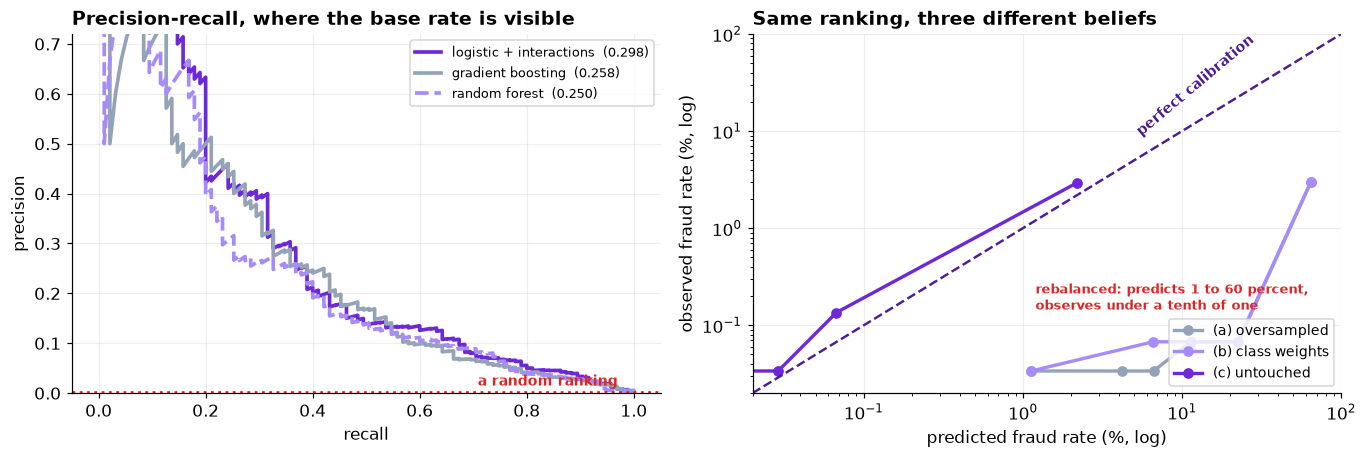

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.3))

ax = axes[0]
for nm, p, col, st in [("logistic + interactions", results["logistic + 2 interactions"], VI, "-"),
                       ("gradient boosting", results["gradient boosting"], MUT, "-"),
                       ("random forest", results["random forest"], LT, "--")]:
    pr, rc, _ = precision_recall_curve(yte, p)
    ax.plot(rc, pr, color=col, lw=2.4, ls=st, label=f"{nm}  ({average_precision_score(yte,p):.3f})")
ax.axhline(yte.mean(), color=RD, lw=1.8, ls=":")
ax.text(0.97, yte.mean()+0.012, "a random ranking", ha="right", color=RD, fontsize=9, fontweight="bold")
ax.set_xlabel("recall"); ax.set_ylabel("precision"); ax.set_ylim(0, 0.72)
ax.set_title("Precision-recall, where the base rate is visible"); ax.legend(fontsize=8.5)

ax = axes[1]
for nm, p, col in [("(a) oversampled", p_over, MUT), ("(b) class weights", p_wt, LT),
                   ("(c) untouched", p_plain, VI)]:
    q = pd.qcut(p, 10, labels=False, duplicates="drop")
    t = pd.DataFrame({"p": p, "y": yte, "q": q}).groupby("q").agg(pr=("p","mean"), ob=("y","mean"))
    t = t[t.ob > 0]
    ax.plot(t.pr*100, t.ob*100, "o-", color=col, lw=2.2, ms=6, label=nm)
lims = [0.02, 100]
ax.plot(lims, lims, color=DK, lw=1.6, ls="--")
ax.text(5.0, 9.0, "perfect calibration", color=DK, fontsize=9, fontweight="bold", rotation=40)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(*lims); ax.set_ylim(*lims)
ax.set_xlabel("predicted fraud rate (%, log)"); ax.set_ylabel("observed fraud rate (%, log)")
ax.text(1.2, 0.145, "rebalanced: predicts 1 to 60 percent,\nobserves under a tenth of one",
        fontsize=8.8, fontweight="bold", color=RD)
ax.set_title("Same ranking, three different beliefs"); ax.legend(fontsize=9, loc="lower right")
plt.tight_layout(); plt.show()

**Left:** the precision-recall curves, where the base rate sits as a floor at 0.32 percent and every model has to be judged against it. The linear model with two hand-added interactions is above both ensembles across almost the whole range. **Right:** the same three sets of predictions on a calibration plot. The untouched model tracks the diagonal; the two rebalanced ones run far below it, predicting tens of percent where the truth is a fraction of one.

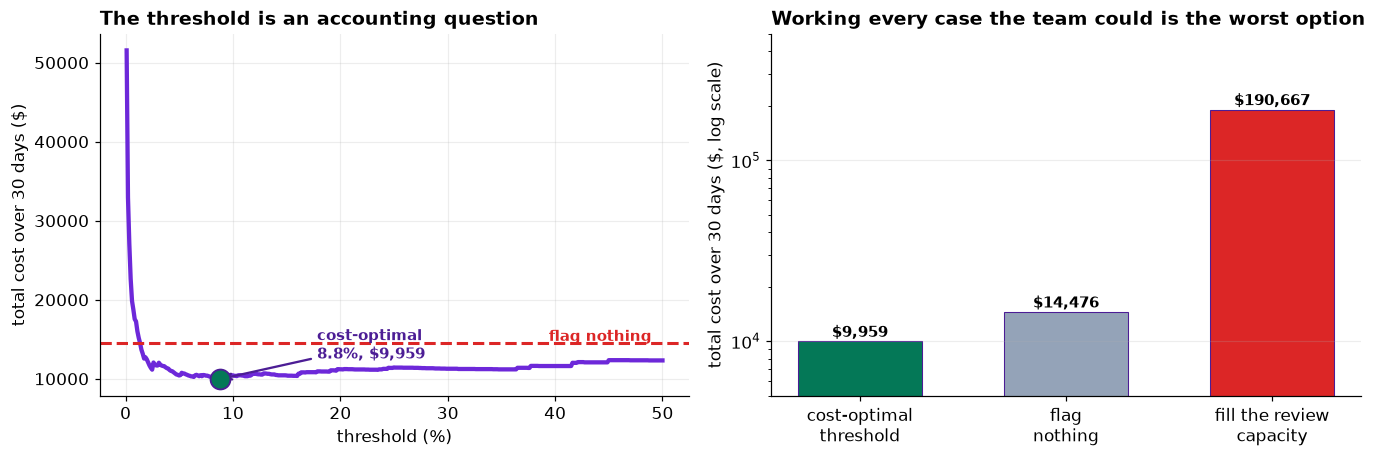

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.3))

ax = axes[0]
ts = np.linspace(0.001, 0.5, 400)
cs = [total_cost(p_plain, t)[0] for t in ts]
ax.plot(ts*100, cs, color=VI, lw=2.8)
ax.axhline(c_none, color=RD, lw=2, ls="--")
ax.text(49, c_none+320, "flag nothing", ha="right", color=RD, fontweight="bold", fontsize=9.5)
ax.plot([bt*100], [bc], "o", ms=13, color=GD, mec=DK, mew=1.2, zorder=5)
ax.annotate(f"cost-optimal\n{bt*100:.1f}%, ${bc:,.0f}", xy=(bt*100, bc), xytext=(bt*100+9, bc+2600),
            fontsize=9.5, fontweight="bold", color=DK,
            arrowprops=dict(arrowstyle="->", color=DK, lw=1.5))
ax.set_xlabel("threshold (%)"); ax.set_ylabel("total cost over 30 days ($)")
ax.set_title("The threshold is an accounting question")

ax = axes[1]
labs = ["cost-optimal\nthreshold", "flag\nnothing", "fill the review\ncapacity"]
vals = [bc, c_none, c_cap]
cols = [GD, MUT, RD]
bars = ax.bar(labs, vals, color=cols, edgecolor=DK, lw=0.7, width=0.6)
for r_, v in zip(bars, vals):
    ax.text(r_.get_x()+r_.get_width()/2, v*1.06, f"${v:,.0f}", ha="center", fontweight="bold", fontsize=10)
ax.set_yscale("log"); ax.set_ylabel("total cost over 30 days ($, log scale)")
ax.set_ylim(5e3, 5e5); ax.grid(axis="x", alpha=0)
ax.set_title("Working every case the team could is the worst option")
plt.tight_layout(); plt.show()

**Left:** total cost against threshold. It is a shallow bowl, which is good news: anything between roughly 4 and 15 percent is close to optimal, so the policy does not need the threshold to be exactly right. **Right:** the three candidate policies. Filling the review queue is worse than having no model at all.

## Step 10 &middot; Ethics, bias, and limits
- **Never report accuracy on a 0.3 percent outcome.** Flagging nothing scores 99.68 percent, and any model that beats it by a decimal has told you nothing.
- **ROC-AUC flatters when negatives dominate.** With 29,000 legitimate transactions in the denominator the false positive rate barely moves, so use precision-recall and quote the base rate beside it.
- **Rebalancing buys ranking and sells calibration.** If the downstream step multiplies the probability by anything, resampling and class weights have broken it, and no ranking metric will say so.
- **A flagged transaction is a person having their card declined.** The $12 in the cost matrix stands for a real customer stranded at a checkout, and it is a placeholder for a harm that is not evenly distributed. Customers who travel, who shop late, or who have just replaced a phone will be flagged more often, and none of those are wrongdoing.
- **Check the flag rate by group before deploying.** This analysis reports one threshold for everybody. A rule that flags one segment at several times the rate of another needs to be examined rather than shipped, and Capstone 37 is about how.
- **Leakage is a data-warehouse problem, not a modelling one.** The fix is a documented feature store that records when each field becomes available, not a smarter analyst noticing in time.
- **The model ages.** Fraud is adversarial: the patterns here were learned from days 1 to 90 and the people producing them adapt. Anything shipped needs its performance re-measured on a schedule, not when somebody wonders.

---
**From analysis to report.** The notebook carries the chain: the costs before the model, the accuracy trap, a time split, a leak caught before anything else, a bake-off the linear baseline wins, three imbalance remedies that rank identically and disagree by a factor of 36 on the level, a threshold derived from the cost matrix, and the review capacity shown not to be the constraint. The written reports turn it into a policy the fraud team can run and a technical account a fellow statistician can audit. Automate the evidence; author the argument.